In [1]:
from datasets import load_dataset
ds = load_dataset("weathon/grpo_dataset")

In [2]:
len(ds["train"])

1337

In [29]:
def format(ans):
    return [
      {
          "role": "assistant",
          "content": ans
      }
  ]

import os
import json
import re
import numpy as np
rollouts = os.listdir("rollouts")
kto_ds = []
for filename in rollouts:
    idx = int(filename.split(".")[0])
    gt = ds['train'][idx]['solution']
    with open(f"rollouts/{filename}", "r") as f:
        data = json.load(f)
    min_diff = 20
    best = 0
    scores = []
    for r in data:
        score = re.search('<score>(.*?)</score>', r)
        if score is not None:
            try:    
                score = float(score.group(1))
                scores.append(score)
            except Exception as e:
                print(f"Error parsing score in idx {idx}: {e}")
                scores.append(float('inf'))
        else:
            scores.append(float('inf'))

    
    scores = np.array(scores)
    tol = 1 + np.abs(gt - 5)/5 * np.abs(gt - 5) * 0.5
    chosen = np.where(np.abs(scores - gt) < tol)[0]
    if np.min(np.abs(scores - gt)) < 1.0:
        chosen = np.concatenate([[np.argmin(np.abs(scores - gt))], chosen])
    chosen = np.unique(chosen)

    pos_count = 0
    for c in chosen:
        kto_ds.append({
            "paper_id": ds['train'][idx]['paper_id'],
            "prompt": ds['train'][idx]['prompt'],
            "completion": format(data[c]),
            "pred": scores[c], 
            "gt": gt,
            "label": True
        })
        pos_count += 1
     
    neg_count = 0
    for i, s in enumerate(scores):
        if abs(s - gt) > 1.5:
            kto_ds.append({
                "paper_id": ds['train'][idx]['paper_id'],
                "prompt": ds['train'][idx]['prompt'],
                "completion": format(data[i]),
                "pred": s,
                "gt": gt,
                "label": False
            })
            neg_count += 1
        if neg_count >= (pos_count + 1) * 1.2:
            break
 

Error parsing score in idx 1290: could not convert string to float: ''
Error parsing score in idx 612: could not convert string to float: '? '
Error parsing score in idx 262: could not convert string to float: '7.o'


In [30]:
positive_count = sum(d['label'] for d in kto_ds)
negative_count = len(kto_ds) - positive_count
print(f"Total samples: {len(kto_ds)}, Positive: {positive_count}, Negative: {negative_count}")

Total samples: 5316, Positive: 2750, Negative: 2566


In [35]:
np.sum(np.array(ds['train']['solution']) > 8)

np.int64(1)

(array([  8.,   4.,  61.,  55.,  75., 137., 149., 175., 229., 189., 394.,
        522., 394., 210., 110.,  35.,   0.,   0.,   0.,   3.]),
 array([ 1.  ,  1.45,  1.9 ,  2.35,  2.8 ,  3.25,  3.7 ,  4.15,  4.6 ,
         5.05,  5.5 ,  5.95,  6.4 ,  6.85,  7.3 ,  7.75,  8.2 ,  8.65,
         9.1 ,  9.55, 10.  ]),
 <BarContainer object of 20 artists>)

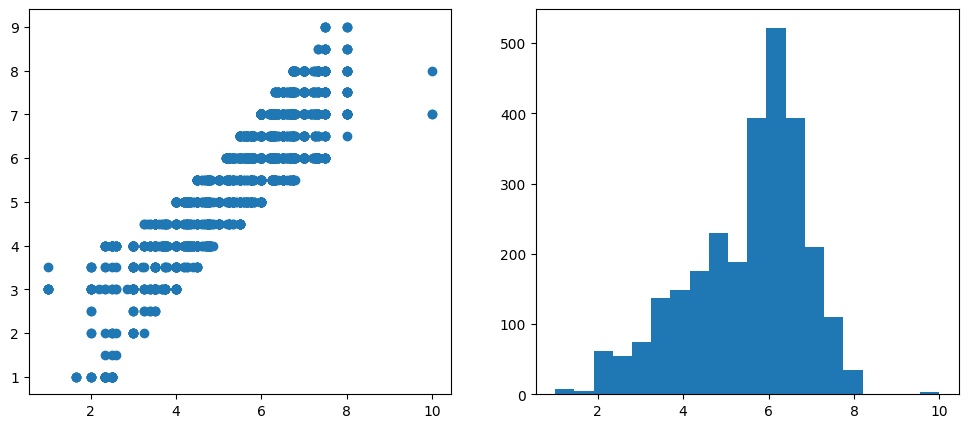

In [36]:
import pylab
x = []
y = []
for i in kto_ds:
    if i["label"]:
        x.append(i["gt"])
        y.append(i["pred"])
pylab.figure(figsize=(12, 5))
pylab.subplot(1, 2, 1)
pylab.scatter(x, y)
pylab.subplot(1, 2, 2)
pylab.hist(x, bins=20) 

In [37]:
all_ids = list(ds['train']['paper_id'])

In [38]:
dpo_ds_train = [d for d in kto_ds if d['paper_id'] in all_ids[:-10]]
dpo_ds_test = [d for d in kto_ds if d['paper_id'] in all_ids[-10:]]

In [39]:
from datasets import Dataset, DatasetDict
dpo_ds_train = Dataset.from_list(dpo_ds_train)
dpo_ds_test = Dataset.from_list(dpo_ds_test)
dpo_ds = DatasetDict(
    {
        "train": dpo_ds_train,
        "test": dpo_ds_test
    }
)

In [40]:
dpo_ds.push_to_hub("weathon/dpo_ds_hf")

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/4 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md:   0%|          | 0.00/811 [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/datasets/weathon/dpo_ds_hf/commit/65389d6dbc85fee1edc0c2cef96692688f1fdcb3', commit_message='Upload dataset', commit_description='', oid='65389d6dbc85fee1edc0c2cef96692688f1fdcb3', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/weathon/dpo_ds_hf', endpoint='https://huggingface.co', repo_type='dataset', repo_id='weathon/dpo_ds_hf'), pr_revision=None, pr_num=None)

In [41]:
sft_ds = dpo_ds.filter(lambda sample: sample['label'])

Filter:   0%|          | 0/5285 [00:00<?, ? examples/s]

Filter:   0%|          | 0/31 [00:00<?, ? examples/s]

In [42]:
sft_ds.push_to_hub("weathon/sft_review")

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/2 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md:   0%|          | 0.00/691 [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/datasets/weathon/sft_review/commit/44670f57451b43093f5a5f9f1c63c47c7b3a4800', commit_message='Upload dataset', commit_description='', oid='44670f57451b43093f5a5f9f1c63c47c7b3a4800', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/weathon/sft_review', endpoint='https://huggingface.co', repo_type='dataset', repo_id='weathon/sft_review'), pr_revision=None, pr_num=None)